In [10]:
from nrem_analysis.constant import PROCESSED_DIR, INTERIM_DIR, MOUSE_IDS_DUAL, FIGURES_DIR

import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
import cmap

plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       320,
    "font.family":       "sans-serif",
    'font.sans-serif':   "Arial",
    "font.size":         18,
    "axes.titlesize":    22,
    "axes.labelsize":    20,
    "xtick.labelsize":   20,
    "ytick.labelsize":   20,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         False,
    # "legend.frameon":    False,
    "figure.constrained_layout.use": True,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})

cyclic_cmap = cmap.Colormap('cmocean:phase').to_mpl()
seq_cmap = cmap.Colormap('cmasher:tropical').to_mpl()
STATE_NAMES = ["continuous", "fragmented", "stationary"]

In [2]:
mv              = "movement_var20"
mouse_id        = "107b"
data_dir        = INTERIM_DIR / mv / mouse_id

sleep           = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
turn_units      = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
head_direction  = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "head_direction.npz")
hd_units        = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "hd_units.npz")
session         = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "session.npz")

nrem            = sleep[sleep['state'] == 'nrem'].intersect(session[session['state'] == 'homecage'])
virtual_hds     = []
states          = []

for i, ep in enumerate(nrem):
    decoded = nap.load_file(data_dir / f"{mouse_id}_{i}.npz")
    vh = nap.Tsd(t=decoded.t, d=decoded.values[:, 3])
    states_i = nap.TsdFrame(t=decoded.t, d=decoded.values[:, :3], columns=STATE_NAMES)
    virtual_hds.append(vh)
    states.append(states_i)

virtual_hds = np.concatenate(virtual_hds)
states = np.concatenate(states)

### Compute preferred angle of HD cells

In [3]:
import scipy.ndimage

tcs = nap.compute_tuning_curves(hd_units, head_direction, bins=360, fs=1000, feature_names=['hd'])
tcs.values = scipy.ndimage.gaussian_filter1d(tcs.values, sigma=1, axis=1, mode="wrap")
# tcs.plot(x='hd', col='unit', col_wrap=4, sharey=False)

pref_angle = tcs.idxmax(dim='hd').to_numpy().squeeze()
hd_order = np.argsort(pref_angle)

### Visualize

In [101]:
offset = 5
start, end = 29250, 29300
idx = np.where((nrem.start > start) & (nrem.start < end))[0] # 40, 73
ep = nrem[idx]

window_size = 4 * 1000
start, end = offset, offset + window_size

hd_spikes = hd_units.restrict(ep)
turn_spikes = turn_units.restrict(ep)
virtual_hd = virtual_hds.restrict(ep)
state = states.restrict(ep)
cont_ep = state['continuous'].threshold(0.5).time_support

pop_vector = turn_spikes.count(bin_size=0.001).sum(axis=1)
pop_vector = pop_vector / 0.001
pop_vector = pop_vector.smooth(std=0.05)

sc_order = np.array(turn_units.keys())[np.argsort(turn_units['turn_index']).values]

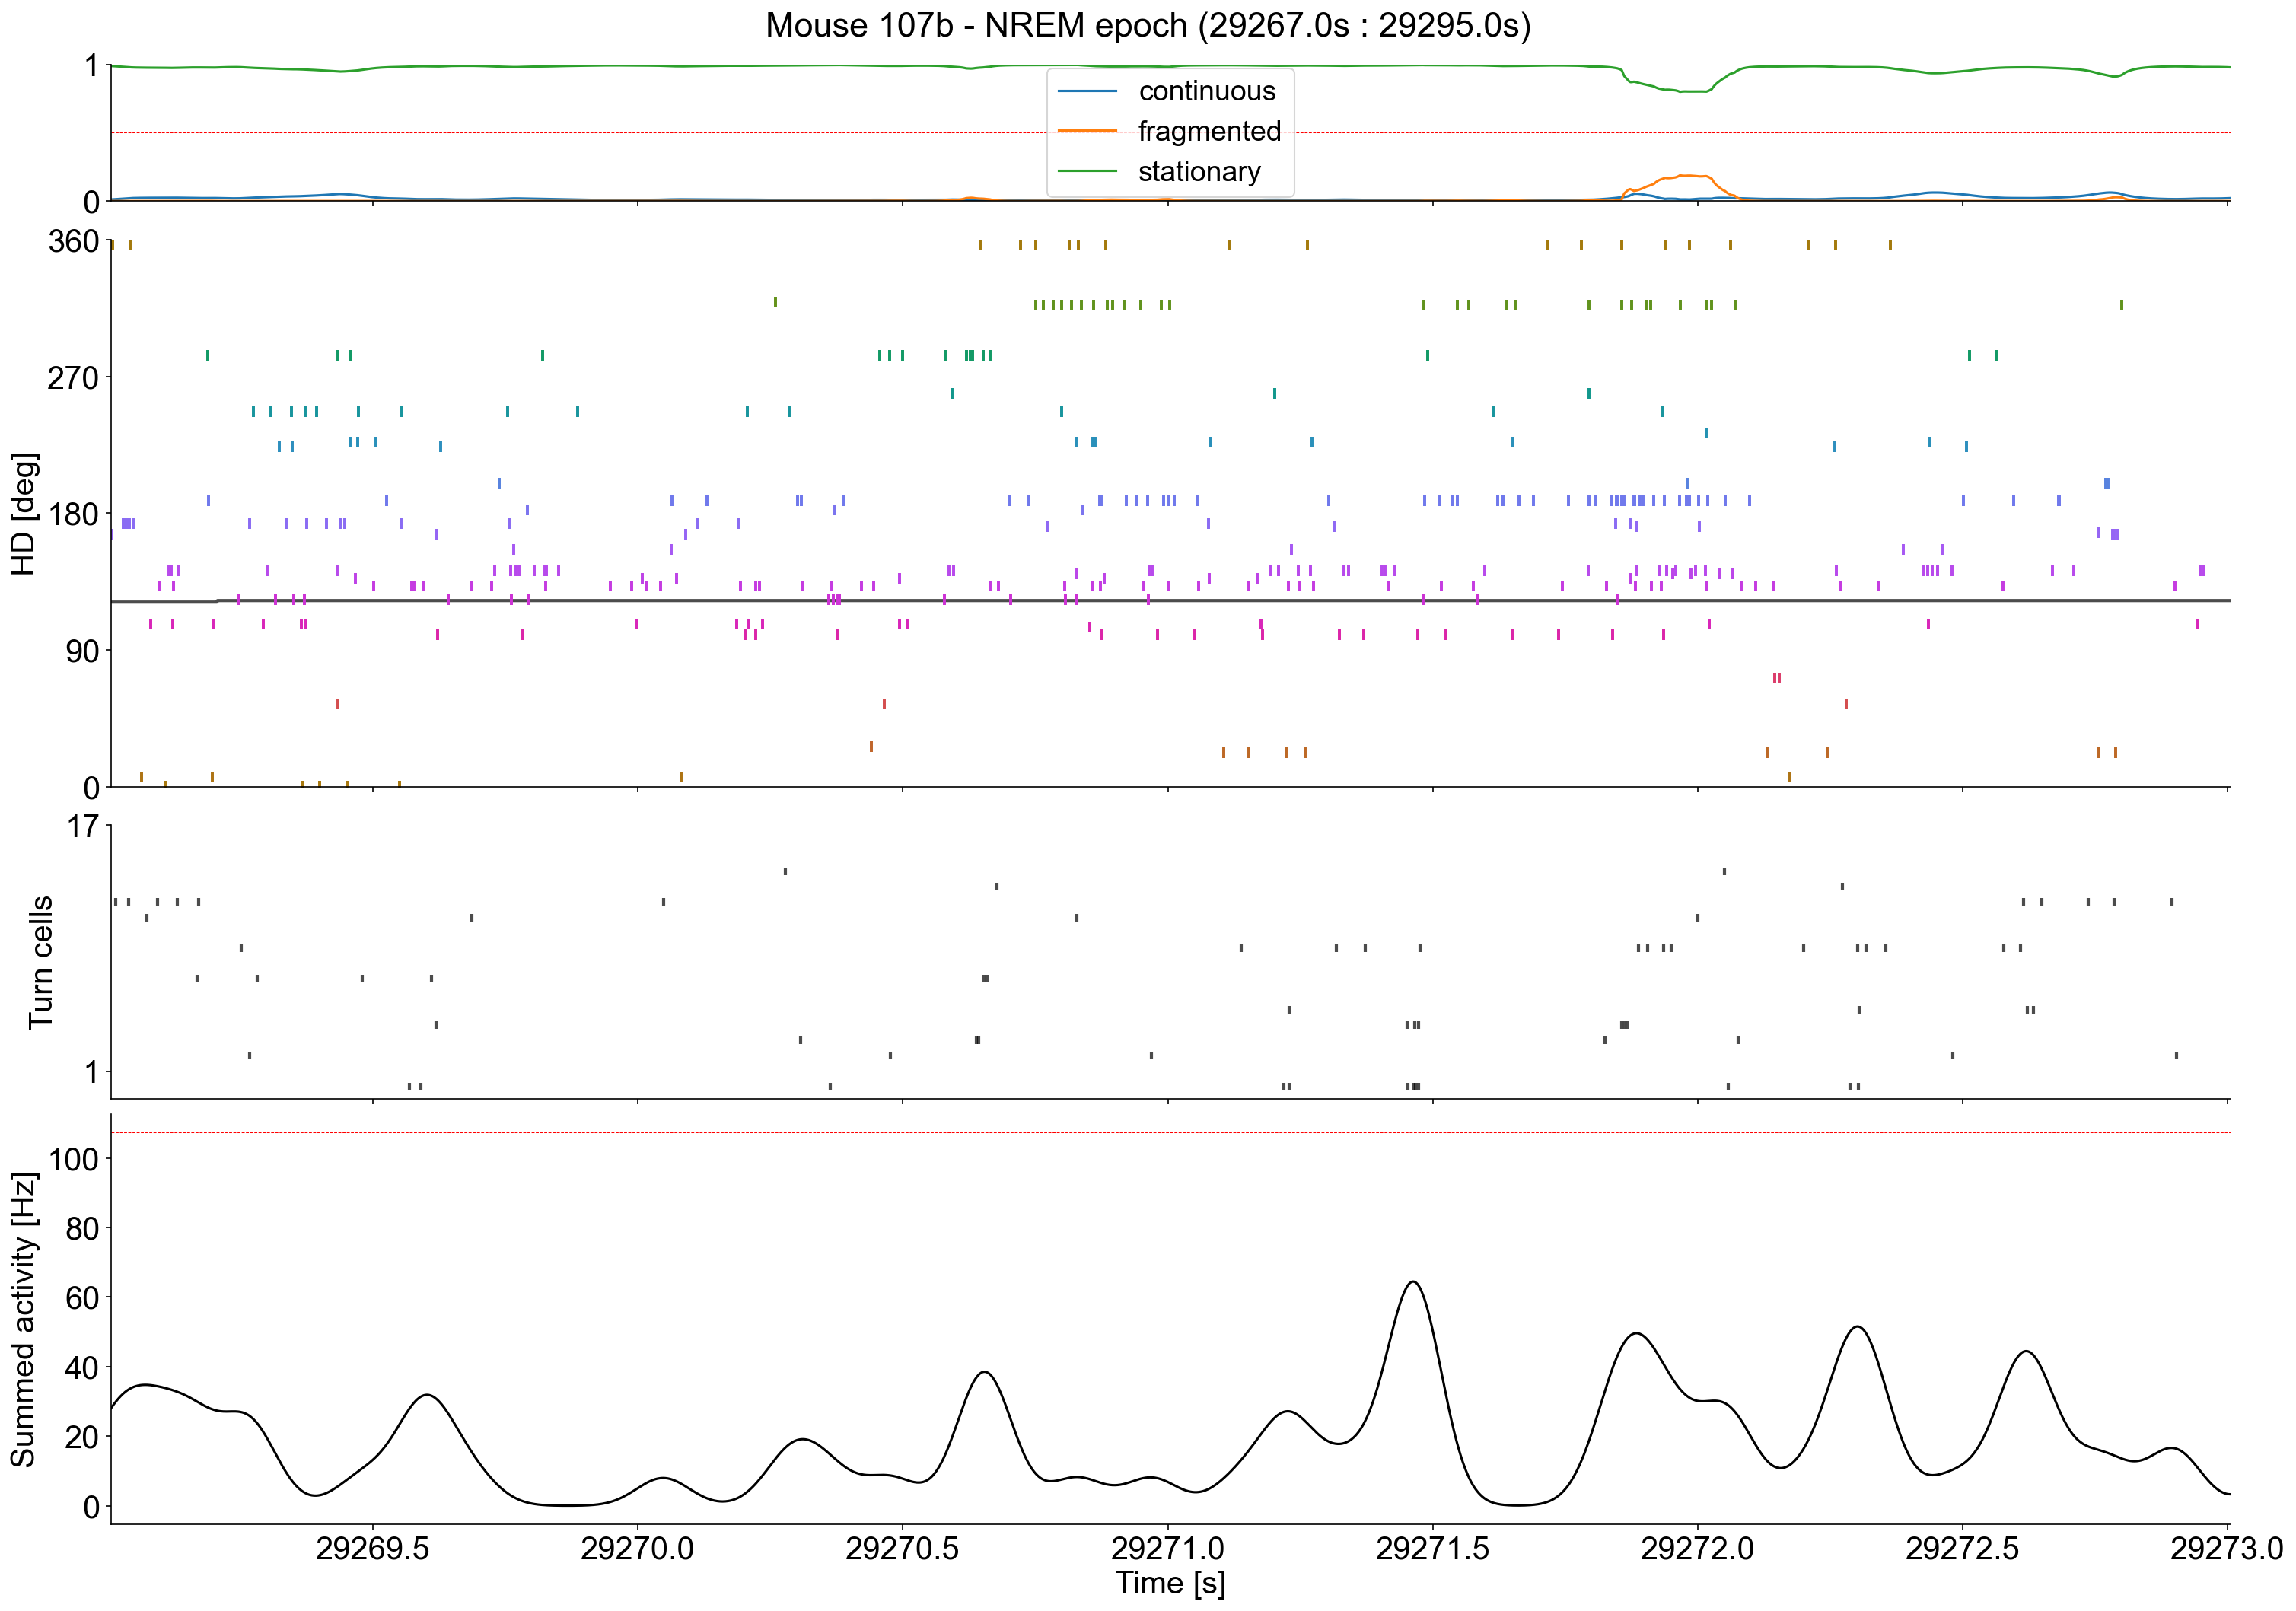

In [102]:
f, ax = plt.subplots(4, 1, figsize=(20, 14), sharex=True, gridspec_kw={'height_ratios': [1, 4, 2, 3]})

start, end = start + window_size//2, end + window_size//2

ax[0].plot(state[start:end], label=state.columns.values)
ax[0].axhline(0.5, color='r', linestyle='--', linewidth=0.5)
ax[0].legend()
ax[0].set_ylim(0., 1.)
ax[0].set_yticks([0, 1])

ax[1].plot(virtual_hd[start:end], color='k', alpha=0.7, linewidth=2)
ax[1].set_ylabel("HD [deg]")

for i, n in enumerate(hd_spikes.keys()):
    pa = pref_angle[n].item()
    ax[1].plot(hd_spikes[n].fillna(pa), '|', color=cyclic_cmap(pa/360), markersize=7, markeredgewidth=1.9)

ax[1].set_xlim(state.index[start], state.index[end])
ax[1].set_ylim(0, 360)
ax[1].set_yticks([0, 90, 180, 270, 360])
ax[1].set_yticklabels(['0', '90', '180', '270', '360'])

for cep in cont_ep:
    ax[0].axvspan(cep.start.item(), cep.end.item(), color='b', alpha=0.2)
    ax[1].axvspan(cep.start.item(), cep.end.item(), color='b', alpha=0.2)

for i, uid in enumerate(sc_order):
    ax[2].plot(turn_spikes[uid].fillna(i), '|', color='k', markersize=5, markeredgewidth=2, alpha=0.7)

ax[2].set_yticks([1, len(turn_spikes)])
ax[2].set_ylabel("Turn cells")

ax[3].set_ylabel("Summed activity [Hz]")
ax[3].plot(pop_vector[start:end], 'k')
ax[3].axhline(pop_vector.mean() + 1*pop_vector.std(), color='r', linestyle='--', linewidth=0.5)

ax[3].set_xlabel("Time [s]")
f.suptitle(f"Mouse {mouse_id} - NREM epoch ({ep.start[0]:.1f}s : {ep.end[-1]:.1f}s)")
plt.savefig(FIGURES_DIR / "new_snapshot1.png")